# Phase 1 Baseline — Random Forest on Amino Acid Composition

A deliberately simple model to establish a **performance floor** for the anti-diabetic
peptide classifier. It replicates the simplest approach common in the ADP literature:
a Random Forest trained on amino acid composition (AAC) features only — the fractional
frequency of each of the 20 standard residues. Any later model that fuses ESM-2
embeddings with physicochemical descriptors must clear this bar to justify its added
complexity.

The model is trained and evaluated on the leakage-safe grouped split
(`dataset_split.csv`), so the metrics here are an honest generalisation estimate, not
an inflated one.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, matthews_corrcoef,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, roc_curve)

SEED = 42
AA = "ACDEFGHIKLMNPQRSTVWY"  # 20 standard amino acids

## 1. Load the leakage-safe dataset

In [2]:
df = pd.read_csv("dataset_split.csv")
print(f"{len(df)} sequences")
print(df["Split"].value_counts().to_string())
df.head()

1932 sequences
Split
train    1754
test      178


,Sequence,Label,Length,Class,NegType,Split
0,AP,1,2,positive,NaN,train
1,LP,1,2,positive,NaN,train
2,IP,1,2,positive,NaN,test
3,MFE,1,3,positive,NaN,test
4,STY,1,3,positive,NaN,train


## 2. Featurise: amino acid composition (AAC)

Each sequence becomes a 20-dimensional vector — the fraction of residues that are each
amino acid. AAC is length-invariant, which suits a dataset whose positive and negative
classes are already length-matched.

In [3]:
def aac(seq):
    seq = str(seq)
    n = len(seq) or 1
    return [seq.count(a) / n for a in AA]

X = np.array([aac(s) for s in df["Sequence"]])
y = df["Label"].to_numpy()

train = (df["Split"] == "train").to_numpy()
test = ~train
print(f"features: {X.shape[1]} (AAC)  |  train: {train.sum()}  test: {test.sum()}")

features: 20 (AAC)  |  train: 1754  test: 178


## 3. Train the Random Forest

In [4]:
clf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
clf.fit(X[train], y[train])
proba = clf.predict_proba(X[test])[:, 1]
pred = (proba >= 0.5).astype(int)

## 4. Performance floor

The eight standard metrics used across the ADP literature (Xie et al., 2025), for direct
comparison.

In [5]:
tn, fp, fn, tp = confusion_matrix(y[test], pred, labels=[0, 1]).ravel()
floor = {
    "ACC":       accuracy_score(y[test], pred),
    "AUC":       roc_auc_score(y[test], proba),
    "MCC":       matthews_corrcoef(y[test], pred),
    "F1":        f1_score(y[test], pred),
    "SN/recall": recall_score(y[test], pred),
    "SP":        tn / (tn + fp),
    "Precision": precision_score(y[test], pred),
}
pd.DataFrame({"baseline (AAC + RF)": floor}).round(3)

,baseline (AAC + RF)
ACC,0.770
AUC,0.853
MCC,0.543
F1,0.796
SN/recall,0.860
SP,0.671
Precision,0.741


## 5. ROC curve

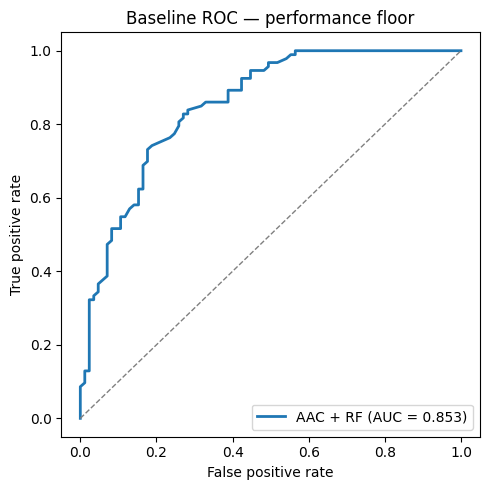

In [6]:
fpr, tpr, _ = roc_curve(y[test], proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, lw=2, label=f"AAC + RF (AUC = {floor['AUC']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Baseline ROC — performance floor"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 6. Which residues drive the floor?

Feature importances over the 20 residues. These should echo the known compositional
signature of ADPs (enrichment of hydrophobic residues such as Leu and Pro), a useful
sanity check that even the simplest model is learning something biologically sensible.

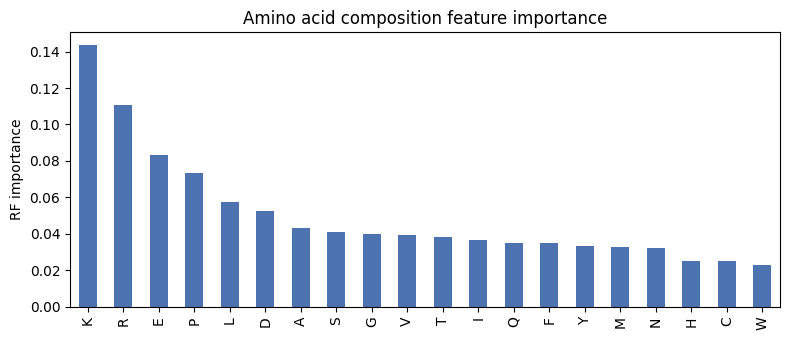

K    0.143
R    0.111
E    0.083
P    0.073
L    0.057
D    0.052
A    0.043
S    0.041
G    0.040
V    0.039
T    0.038
I    0.037
Q    0.035
F    0.035
Y    0.033
M    0.033
N    0.032
H    0.025
C    0.025
W    0.023
dtype: float64

In [7]:
imp = pd.Series(clf.feature_importances_, index=list(AA)).sort_values(ascending=False)
plt.figure(figsize=(8, 3.5))
imp.plot(kind="bar", color="#4C72B0")
plt.ylabel("RF importance"); plt.title("Amino acid composition feature importance")
plt.tight_layout(); plt.show()
imp.round(3)